###  Model (1) Linear Regression Model

In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
import numpy as np

# Load the CSV files into DataFrames
train_file_path = "/Users/ARahim/Documents/GitHub/immo-eliza-ml/Data/ftrain_house.csv"
test_file_path = "/Users/ARahim/Documents/GitHub/immo-eliza-ml/Data/ftest_house.csv"

df_train = pd.read_csv(train_file_path)
df_test = pd.read_csv(test_file_path)

# Group columns into num_features, fl_features, and cat_features
num_features = ['total_area_sqm', 'surface_land_sqm', 'nbr_frontages', 'nbr_bedrooms', 
                'terrace_sqm', 'garden_sqm', 'primary_energy_consumption_sqm']

fl_features = ['fl_furnished', 'fl_open_fire', 'fl_terrace', 'fl_garden', 
               'fl_swimming_pool', 'fl_floodzone', 'fl_double_glazing']

cat_features = ["subproperty_type", "region", "province", "locality", 
                "equipped_kitchen", "state_building", "epc", "heating_type"]

# Identify and drop outliers for numeric features using IQR
def remove_outliers(df, columns, tolerance=1.5):
    for column in columns:
        q1 = df[column].quantile(0.25)
        q3 = df[column].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - tolerance * iqr
        upper_bound = q3 + tolerance * iqr
        df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df

# Remove outliers from the training data
df_train = remove_outliers(df_train, num_features)

# Remove outliers from the testing data using the same tolerance as the training data
df_test = remove_outliers(df_test, num_features)

# Prepare the data for modeling
X_train = df_train.drop(columns=['price'])
y_train = df_train['price']
X_test = df_test.drop(columns=['price'])
y_test = df_test['price']

# Train the linear regression model with cross-validation
model = LinearRegression()
cv_scores = cross_val_score(model, X_train, y_train, cv=5)  # 5-fold cross-validation
mean_cv_score = np.mean(cv_scores)

# Train the linear regression model
model.fit(X_train, y_train)

# Evaluate the model
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print("Mean Cross-Validation Score:", mean_cv_score)
print("Train Score:", train_score)
print("Test Score:", test_score)


Mean Cross-Validation Score: 0.47408499666865056
Train Score: 0.48115680311433184
Test Score: 0.45280329082075854


###  Model (2)  Lasso Regression Model

In [21]:
import pandas as pd
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

# Load the CSV files into DataFrames
train_file_path = "/Users/ARahim/Documents/GitHub/immo-eliza-ml/Data/ftrain_house.csv"
test_file_path = "/Users/ARahim/Documents/GitHub/immo-eliza-ml/Data/ftest_house.csv"

df_train = pd.read_csv(train_file_path)
df_test = pd.read_csv(test_file_path)

# Identify and drop outliers for numeric features using IQR
def remove_outliers(df, columns, tolerance=1.5):
    for column in columns:
        q1 = df[column].quantile(0.25)
        q3 = df[column].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - tolerance * iqr
        upper_bound = q3 + tolerance * iqr
        df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df

# Remove outliers from the training data
num_features = ['total_area_sqm', 'surface_land_sqm', 'nbr_frontages', 'nbr_bedrooms', 
                'terrace_sqm', 'garden_sqm', 'primary_energy_consumption_sqm']
df_train = remove_outliers(df_train, num_features)

# Remove outliers from the testing data using the same tolerance as the training data
df_test = remove_outliers(df_test, num_features)

# Prepare the data for modeling
X_train = df_train.drop(columns=['price'])
y_train = df_train['price']
X_test = df_test.drop(columns=['price'])
y_test = df_test['price']

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the Lasso regression model with cross-validation
lasso_model = Lasso(alpha=10.0, max_iter=10000)  # Increase alpha
cv_scores = cross_val_score(lasso_model, X_train_scaled, y_train, cv=5)  # 5-fold cross-validation
mean_cv_score = cv_scores.mean()

# Train the Lasso regression model
lasso_model.fit(X_train_scaled, y_train)

# Evaluate the model
train_score = lasso_model.score(X_train_scaled, y_train)
test_score = lasso_model.score(X_test_scaled, y_test)

print("Mean Cross-Validation Score:", mean_cv_score)
print("Train Score:", train_score)
print("Test Score:", test_score)



Mean Cross-Validation Score: 0.47397198772830745
Train Score: 0.4811566727263886
Test Score: 0.4528128145024093


###  Model (3)  Elastic Net Model 

In [22]:
import pandas as pd
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import StandardScaler

# Load the CSV files into DataFrames
train_file_path = "/Users/ARahim/Documents/GitHub/immo-eliza-ml/Data/ftrain_house.csv"
test_file_path = "/Users/ARahim/Documents/GitHub/immo-eliza-ml/Data/ftest_house.csv"

df_train = pd.read_csv(train_file_path)
df_test = pd.read_csv(test_file_path)

# Identify and drop outliers for numeric features using IQR
def remove_outliers(df, columns, tolerance=1.5):
    for column in columns:
        q1 = df[column].quantile(0.25)
        q3 = df[column].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - tolerance * iqr
        upper_bound = q3 + tolerance * iqr
        df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df

# Remove outliers from the training data
num_features = ['total_area_sqm', 'surface_land_sqm', 'nbr_frontages', 'nbr_bedrooms', 
                'terrace_sqm', 'garden_sqm', 'primary_energy_consumption_sqm']
df_train = remove_outliers(df_train, num_features)

# Remove outliers from the testing data using the same tolerance as the training data
df_test = remove_outliers(df_test, num_features)

# Prepare the data for modeling
X_train = df_train.drop(columns=['price'])
y_train = df_train['price']
X_test = df_test.drop(columns=['price'])
y_test = df_test['price']

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the Elastic Net regression model with cross-validation
elastic_net_model = ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=10000)  # alpha is the regularization strength, l1_ratio is the mixing parameter between L1 and L2 penalties
cv_scores = cross_val_score(elastic_net_model, X_train_scaled, y_train, cv=5)  # 5-fold cross-validation
mean_cv_score = cv_scores.mean()

# Train the Elastic Net regression model
elastic_net_model.fit(X_train_scaled, y_train)

# Evaluate the model
train_score = elastic_net_model.score(X_train_scaled, y_train)
test_score = elastic_net_model.score(X_test_scaled, y_test)

print("Mean Cross-Validation Score:", mean_cv_score)
print("Train Score:", train_score)
print("Test Score:", test_score)


Mean Cross-Validation Score: 0.4597667814563707
Train Score: 0.46231019690889374
Test Score: 0.45102605022056985


###  Model (4) Random Forest Model

In [17]:
import pandas as pd
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

# Load the CSV files into DataFrames
train_file_path = "/Users/ARahim/Documents/GitHub/immo-eliza-ml/Data/ftrain_house.csv"
test_file_path = "/Users/ARahim/Documents/GitHub/immo-eliza-ml/Data/ftest_house.csv"

df_train = pd.read_csv(train_file_path)
df_test = pd.read_csv(test_file_path)

# Identify and drop outliers for numeric features using IQR
def remove_outliers(df, columns, tolerance=1.5):
    for column in columns:
        q1 = df[column].quantile(0.25)
        q3 = df[column].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - tolerance * iqr
        upper_bound = q3 + tolerance * iqr
        df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df

# Remove outliers from the training data
num_features = ['total_area_sqm', 'surface_land_sqm', 'nbr_frontages', 'nbr_bedrooms', 
                'terrace_sqm', 'garden_sqm', 'primary_energy_consumption_sqm']
df_train = remove_outliers(df_train, num_features)

# Remove outliers from the testing data using the same tolerance as the training data
df_test = remove_outliers(df_test, num_features)

# Prepare the data for modeling
X_train = df_train.drop(columns=['price'])
y_train = df_train['price']
X_test = df_test.drop(columns=['price'])
y_test = df_test['price']

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the Random Forest regression model with cross-validation
random_forest_model = RandomForestRegressor(n_estimators=100, random_state=42)  # Use 100 decision trees
cv_scores = cross_val_score(random_forest_model, X_train_scaled, y_train, cv=5)  # 5-fold cross-validation
mean_cv_score = cv_scores.mean()

# Train the Random Forest regression model
random_forest_model.fit(X_train_scaled, y_train)

# Evaluate the model
train_score = random_forest_model.score(X_train_scaled, y_train)
test_score = random_forest_model.score(X_test_scaled, y_test)

print("Mean Cross-Validation Score:", mean_cv_score)
print("Train Score:", train_score)
print("Test Score:", test_score)


Mean Cross-Validation Score: 0.6531870296534088
Train Score: 0.9546695248983852
Test Score: 0.565259373964009


### Checking features importance - Random Forest

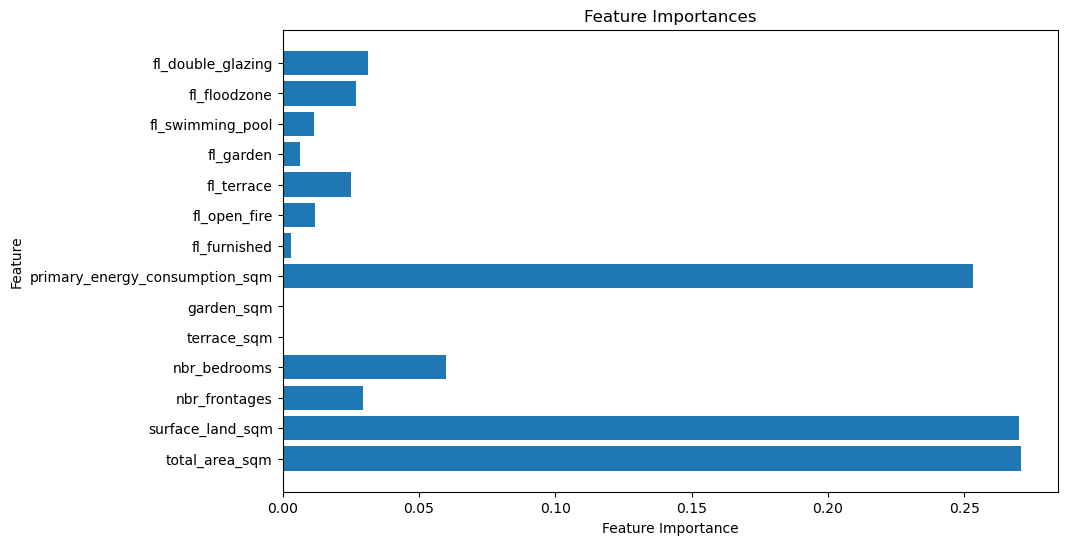

In [12]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

# Load the CSV files into DataFrames
train_file_path = "/Users/ARahim/Documents/GitHub/immo-eliza-ml/Data/ftrain_house.csv"
test_file_path = "/Users/ARahim/Documents/GitHub/immo-eliza-ml/Data/ftest_house.csv"

df_train = pd.read_csv(train_file_path)
df_test = pd.read_csv(test_file_path)

# Group columns into num_features, fl_features, and cat_features
num_features = ['total_area_sqm', 'surface_land_sqm', 'nbr_frontages', 'nbr_bedrooms', 
                'terrace_sqm', 'garden_sqm', 'primary_energy_consumption_sqm']

fl_features = ['fl_furnished', 'fl_open_fire', 'fl_terrace', 'fl_garden', 
               'fl_swimming_pool', 'fl_floodzone', 'fl_double_glazing']

cat_features = ["subproperty_type", "region", "province", "locality", 
                "equipped_kitchen", "state_building", "epc", "heating_type"]

# Identify and drop outliers for numeric features using IQR
def remove_outliers(df, columns, tolerance=1.5):
    for column in columns:
        q1 = df[column].quantile(0.25)
        q3 = df[column].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - tolerance * iqr
        upper_bound = q3 + tolerance * iqr
        df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df

df_train = remove_outliers(df_train, num_features)

# Prepare the data for modeling
X_train = df_train[num_features + fl_features]
y_train = df_train['price']

# Train a Random Forest model
rf_model = RandomForestRegressor()
rf_model.fit(X_train, y_train)

# Get feature importances
feature_importances = rf_model.feature_importances_

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(num_features + fl_features, feature_importances)
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Feature Importances')
plt.show()
